In [1]:
#env-test-imports
import sys
import numpy as np
import scipy
import matplotlib
import sympy as sp
import qutip as qt
import pandas as pd

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SymPy:", sp.__version__)
print("QuTiP:", qt.__version__)
print("Pandas:", pd.__version__)
print("Environment test passed.")

Python: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.4.4
SciPy: 1.17.1
Matplotlib: 3.10.9
SymPy: 1.14.0
QuTiP: 5.2.3
Pandas: 3.0.2
Environment test passed.


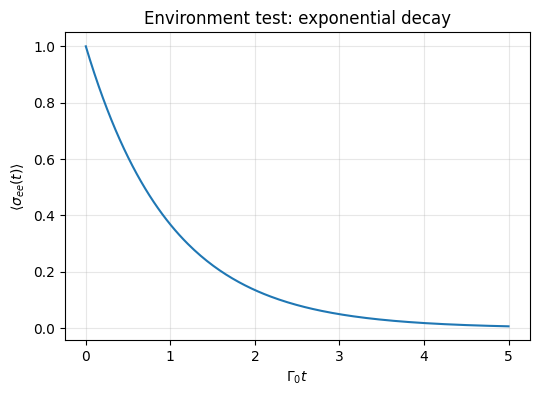

In [2]:
#env-test-basic-plot
import matplotlib.pyplot as plt

x = np.linspace(0, 5, 200)
y = np.exp(-x)

plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.xlabel(r"$\Gamma_0 t$")
plt.ylabel(r"$\langle \sigma_{ee}(t) \rangle$")
plt.title("Environment test: exponential decay")
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
#env-test-latex-output
from IPython.display import display, Math

Gamma0, Gammac, t = sp.symbols(r"\Gamma_0 \Gamma_c t", positive=True)
expr = sp.exp(-(Gamma0 + Gammac) * t)

display(Math(r"\langle \sigma_{ee}(t) \rangle = " + sp.latex(expr)))

<IPython.core.display.Math object>

In [4]:
#env-test-qutip-operators
sigma_minus = qt.sigmam()
sigma_plus = qt.sigmap()
sigma_ee = sigma_plus * sigma_minus

print("sigma_minus:")
print(sigma_minus)

print("sigma_ee:")
print(sigma_ee)

sigma_minus:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0.]
 [1. 0.]]
sigma_ee:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]


In [9]:
#import-reload-test-operators
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.operators as ops
importlib.reload(ops)

print("operators.py path:", ops.__file__)
print("Available names:")
print([name for name in dir(ops) if not name.startswith("_")])

print("Has build_many_atom_operators:", hasattr(ops, "build_many_atom_operators"))
print("Has build_collapse_operators:", hasattr(ops, "build_collapse_operators"))

operators.py path: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\src\operators.py
Available names:
['build_collapse_operators', 'build_many_atom_operators', 'identity_single', 'ket_e_single', 'ket_g_single', 'local_operator', 'np', 'qt', 'sigma_ee_single', 'sigma_minus_single', 'sigma_plus_single']
Has build_many_atom_operators: True
Has build_collapse_operators: True


In [10]:
#test-src-imports
from src.operators import build_many_atom_operators, build_collapse_operators
from src.master_equation import solve_many_atom_master_equation
from src.dicke import solve_dicke_rate_equation, compute_dicke_observables
from src.trajectories import solve_manual_quantum_trajectories

print("src imports worked.")

src imports worked.


In [11]:
#src-function-sanity-test
num_atoms_test = 2
gamma0_test = 1.0
gammac_test = 5.0

operators_test = build_many_atom_operators(num_atoms_test)
collapse_ops_test = build_collapse_operators(
    num_atoms=num_atoms_test,
    gamma0=gamma0_test,
    gammac=gammac_test,
)

print("Available operator keys:", operators_test.keys())
print("Hilbert dimension:", 2**num_atoms_test)
print("psi0 shape:", operators_test["psi0"].shape)
print("rho0 shape:", operators_test["rho0"].shape)
print("J_minus shape:", operators_test["J_minus"].shape)
print("Total population operator shape:", operators_test["total_excited_population_operator"].shape)
print("Number of collapse operators:", len(collapse_ops_test))

Available operator keys: dict_keys(['sigma_minus_ops', 'sigma_ee_ops', 'J_minus', 'total_excited_population_operator', 'psi0', 'rho0'])
Hilbert dimension: 4
psi0 shape: (4, 1)
rho0 shape: (4, 4)
J_minus shape: (4, 4)
Total population operator shape: (4, 4)
Number of collapse operators: 3
